In [1]:


# === SETUP: load the provided data files (regenerate them if missing) ===
import os
import numpy as np
import pandas as pd

def build_datasets(csv_path='ecommerce_customers.csv',
                   xlsx_path='transactions.xlsx', seed=42, verbose=False):
    """Generate a realistic e-commerce customer + transactions dataset.

    Baked-in realism for EDA / feature engineering practice:
      - right-skewed monetary columns (total_spend) with a few 'whale' outliers
      - class imbalance in is_churned (~20-30%)
      - real signal: churn depends on recency, order count and support tickets
      - missing values in age / gender / city
      - a high-cardinality 'city' column (long tail of rare cities)
      - customers with zero orders (no last_order_date) -> dormant
    The Excel file is order-level and is CONSISTENT with the customer table
    (num_orders / total_spend / last_order_date are derived from it).
    """
    rng = np.random.default_rng(seed)
    N = 2500
    start = pd.Timestamp('2021-01-01')
    end = pd.Timestamp('2024-06-30')
    horizon = (end - start).days

    cust = np.array([f'CUST{i+1:05d}' for i in range(N)])
    signup_off = rng.integers(0, horizon - 60, N)
    signup = start + pd.to_timedelta(signup_off, unit='D')

    # order counts: overdispersed (gamma-poisson), some customers have zero
    lam = rng.gamma(2.0, 1.6, N)
    num_orders = rng.poisson(lam)

    # ---- order-level transactions (vectorised) ----
    counts = num_orders
    tot = int(counts.sum())
    cust_rep = np.repeat(cust, counts)
    signup_rep = np.repeat(signup_off, counts)
    span = np.maximum(horizon - signup_off, 1)
    span_rep = np.repeat(span, counts)
    off = (rng.random(tot) * span_rep).astype(int)
    tx_off = signup_rep + off
    tx_date = start + pd.to_timedelta(tx_off, unit='D')
    amount = rng.lognormal(3.2, 0.8, tot).round(2)        # right-skewed (~tens of currency)
    category = rng.choice(['Electronics', 'Fashion', 'Grocery', 'Home', 'Books'],
                          tot, p=[.20, .30, .25, .15, .10])
    tx = pd.DataFrame({'customer_id': cust_rep, 'order_date': tx_date,
                       'amount': amount, 'category': category}).sort_values(
        ['customer_id', 'order_date']).reset_index(drop=True)

    # ---- aggregate transactions -> customer level ----
    agg = tx.groupby('customer_id').agg(
        total_spend=('amount', 'sum'),
        first_order=('order_date', 'min'),
        last_order=('order_date', 'max'),
    ).reset_index()

    df = pd.DataFrame({'customer_id': cust, 'signup_date': signup,
                       'num_orders': num_orders})
    df = df.merge(agg, on='customer_id', how='left')
    df['total_spend'] = df['total_spend'].fillna(0).round(2)

    # ---- demographics & account attributes ----
    df['age'] = np.clip(rng.normal(38, 12, N), 18, 82).round().astype(int)
    df['gender'] = rng.choice(['M', 'F', 'Other'], N, p=[.48, .48, .04])

    majors = ['Mumbai', 'Delhi', 'Bengaluru', 'Hyderabad', 'Chennai', 'Pune', 'Kolkata']
    rare = ['Jaipur', 'Surat', 'Indore', 'Bhopal', 'Patna', 'Nagpur',
            'Kochi', 'Coimbatore', 'Visakhapatnam', 'Lucknow']
    pool = majors + rare
    w = np.array([.17, .15, .14, .12, .10, .08, .06] + [.013] * 10)
    w = w / w.sum()
    df['city'] = rng.choice(pool, N, p=w)

    df['plan'] = rng.choice(['Basic', 'Standard', 'Premium'], N, p=[.50, .35, .15])
    df['device'] = rng.choice(['Mobile', 'Desktop', 'Tablet'], N, p=[.60, .32, .08])
    df['payment_method'] = rng.choice(['Card', 'UPI', 'Wallet', 'NetBanking'],
                                      N, p=[.40, .35, .15, .10])
    df['support_tickets'] = rng.poisson(0.6, N)
    df['email_opt_in'] = rng.choice([0, 1], N, p=[.35, .65])

    # ---- churn target with real signal (recency / orders / tickets) ----
    last = pd.to_datetime(df['last_order'])
    days_since = (end - last).dt.days
    days_since_filled = days_since.fillna(horizon).to_numpy()
    z = (-2.75
         + 0.0019 * days_since_filled
         + 0.30 * df['support_tickets'].to_numpy()
         - 0.05 * df['num_orders'].to_numpy()
         + 0.70 * (df['num_orders'].to_numpy() == 0))
    p = 1 / (1 + np.exp(-z))
    df['is_churned'] = (rng.random(N) < p).astype(int)

    # ---- format dates as ISO strings (NaT -> ) ----
    df = df.rename(columns={'first_order': 'first_order_date',
                            'last_order': 'last_order_date'})
    for c in ['signup_date', 'first_order_date', 'last_order_date']:
        df[c] = pd.to_datetime(df[c]).dt.date.astype('string')

    df = df[['customer_id', 'signup_date', 'first_order_date', 'last_order_date',
             'age', 'gender', 'city', 'plan', 'device', 'payment_method',
             'num_orders', 'total_spend', 'support_tickets', 'email_opt_in',
             'is_churned']]

    # ---- inject missing values AFTER computing the target ----
    def punch(col, frac):
        idx = rng.choice(N, int(frac * N), replace=False)
        df.loc[idx, col] = np.nan
    punch('age', 0.07)
    punch('gender', 0.04)
    punch('city', 0.02)

    # ---- write files ----
    df.to_csv(csv_path, index=False)
    tx_out = tx.copy()
    tx_out['order_date'] = pd.to_datetime(tx_out['order_date']).dt.date.astype('string')
    tx_out.to_excel(xlsx_path, index=False)

    if verbose:
        print('customers:', df.shape, '| transactions:', tx_out.shape)
        print('churn rate:', round(df["is_churned"].mean(), 3))
        print('total_spend skew:', round(df["total_spend"].skew(), 2))
        print('missing age:', int(df["age"].isna().sum()),
              '| missing city:', int(df["city"].isna().sum()))
        print('zero-order customers:', int((df["num_orders"] == 0).sum()))
        print('distinct cities:', df["city"].nunique())
    return df, tx_out

if not (os.path.exists('ecommerce_customers.csv') and os.path.exists('transactions.xlsx')):
    build_datasets()   # creates the two resource files locally
    print('Generated dataset files.')
else:
    print('Found the provided dataset files.')

Generated dataset files.


In [2]:
# Load the customer table (parse the date columns as real datetimes)
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

df = pd.read_csv('ecommerce_customers.csv',
                 parse_dates=['signup_date', 'first_order_date', 'last_order_date'])
print('Loaded', df.shape[0], 'customers x', df.shape[1], 'columns')
df.head()

Loaded 2500 customers x 15 columns


,customer_id,signup_date,first_order_date,last_order_date,age,gender,city,plan,device,payment_method,num_orders,total_spend,support_tickets,email_opt_in,is_churned
0,CUST00001,2021-04-19,NaT,NaT,31.0,F,Chennai,Premium,Desktop,Card,0,0.00,2,0,0
1,CUST00002,2023-07-31,NaT,NaT,54.0,F,Hyderabad,Standard,Desktop,Wallet,0,0.00,1,0,1
2,CUST00003,2023-03-07,2023-05-22,2023-05-22,43.0,Other,Pune,Premium,Mobile,Wallet,1,39.17,1,0,0
3,CUST00004,2022-06-18,2022-07-02,2022-07-02,28.0,F,Pune,Standard,Desktop,Card,1,2.74,1,1,0
4,CUST00005,2022-06-11,2022-09-18,2024-06-15,30.0,F,Mumbai,Standard,Mobile,Wallet,4,133.80,0,0,0


1. First look — profile the dataset

In [3]:
# -----------------------------------------------------------
# 🔹 1A. STRUCTURE: what are we working with?
# -----------------------------------------------------------
df.info()   # column types + non-null counts


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   customer_id       2500 non-null   object        
 1   signup_date       2500 non-null   datetime64[ns]
 2   first_order_date  2131 non-null   datetime64[ns]
 3   last_order_date   2131 non-null   datetime64[ns]
 4   age               2325 non-null   float64       
 5   gender            2400 non-null   object        
 6   city              2450 non-null   object        
 7   plan              2500 non-null   object        
 8   device            2500 non-null   object        
 9   payment_method    2500 non-null   object        
 10  num_orders        2500 non-null   int64         
 11  total_spend       2500 non-null   float64       
 12  support_tickets   2500 non-null   int64         
 13  email_opt_in      2500 non-null   int64         
 14  is_churned        2500 n

In [4]:
# -----------------------------------------------------------
# 🔹 1B. QUALITY SNAPSHOT: missingness + the target balance
# -----------------------------------------------------------
print('Missing values (%):')
print((df.isna().mean() * 100).round(1).sort_values(ascending=False).head(6))
print('\nChurn rate (target):', round(df['is_churned'].mean(), 3))
print('Customers with zero orders:', int((df['num_orders'] == 0).sum()))

Missing values (%):
first_order_date    14.8
last_order_date     14.8
age                  7.0
gender               4.0
city                 2.0
signup_date          0.0
dtype: float64

Churn rate (target): 0.166
Customers with zero orders: 369


In [5]:
# 1. Is customer_id unique?
print("Customer IDs unique:", df['customer_id'].is_unique)
print("Duplicate customer IDs:", df['customer_id'].duplicated().sum())

# 2. Numeric summary
print("\nNumeric summary:")
print(df.describe())

# 3. Three issues I can see:
# - Missing values exist in columns such as age, gender, and city.
# - Some customers have zero orders / zero total spend.
# - Monetary features such as total_spend can be strongly right-skewed
#   and may contain unusually large values.


Customer IDs unique: True
Duplicate customer IDs: 0

Numeric summary:
                      signup_date               first_order_date  \
count                        2500                           2131   
mean   2022-08-29 07:45:59.040000  2023-03-07 03:13:56.227123200   
min           2021-01-01 00:00:00            2021-01-24 00:00:00   
25%           2021-10-30 00:00:00            2022-07-06 12:00:00   
50%           2022-08-24 12:00:00            2023-04-22 00:00:00   
75%           2023-07-01 00:00:00            2023-12-05 00:00:00   
max           2024-04-30 00:00:00            2024-06-28 00:00:00   
std                           NaN                            NaN   

                     last_order_date          age   num_orders  total_spend  \
count                           2131  2325.000000  2500.000000  2500.000000   
mean   2024-01-01 16:56:59.239793664    37.888602     3.260800   112.272900   
min              2021-03-23 00:00:00    18.000000     0.000000     0.000000   
2

2. Univariate analysis — numeric variables

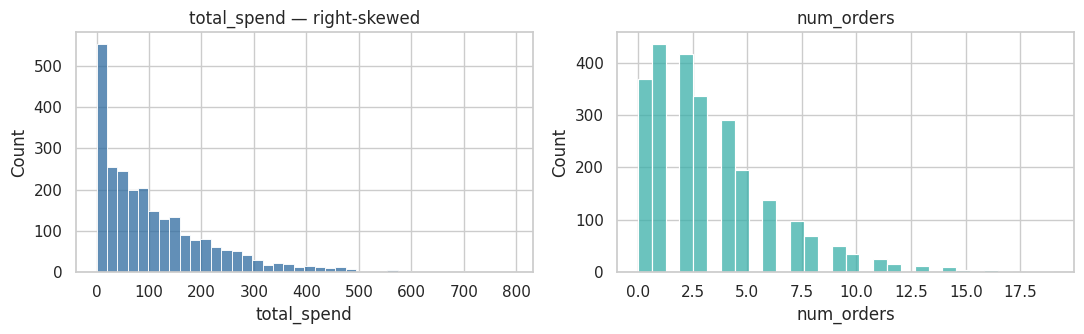

In [6]:
# -----------------------------------------------------------
# 🔹 2A. DISTRIBUTION OF SPEND  (note the long right tail)
# -----------------------------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
sns.histplot(df['total_spend'], bins=40, ax=ax[0], color='#2D6A9F')
ax[0].set_title('total_spend — right-skewed')
sns.histplot(df['num_orders'], bins=30, ax=ax[1], color='#3AAFA9')
ax[1].set_title('num_orders')
plt.tight_layout(); plt.show()

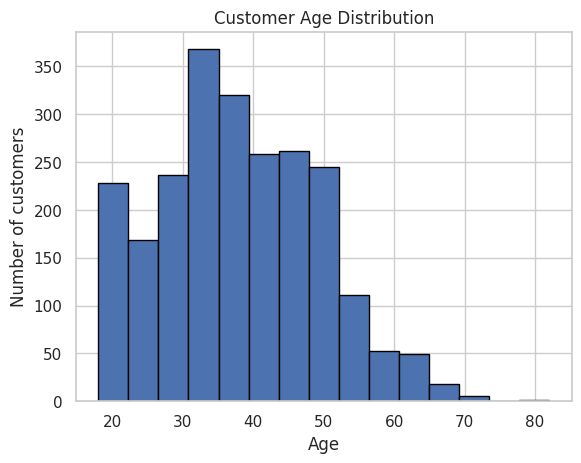

In [7]:
# 1. Histogram of age (drop NaN)
df['age'].dropna().hist(
    bins=15,
    edgecolor='black'
)

plt.xlabel('Age')
plt.ylabel('Number of customers')
plt.title('Customer Age Distribution')
plt.show()

# 2. Shape description:
# The age distribution should be roughly bell-shaped / symmetric,
# centered around the late 30s, with values mainly between about 18 and 82.
# There should not be obvious impossible age values.

3. Summary statistics & skew

In [8]:

# -----------------------------------------------------------
# 🔹 3A. MEAN vs MEDIAN ON A SKEWED COLUMN
# -----------------------------------------------------------
# When data is right-skewed, the mean is pulled up by big spenders.
spend = df['total_spend']
print('mean  :', round(spend.mean(), 1))
print('median:', round(spend.median(), 1))
print('skew  :', round(spend.skew(), 2), ' (> 0 means right-skewed)')
print('\nThe mean > median gap is the skew talking.')

mean  : 112.3
median: 79.1
skew  : 1.73  (> 0 means right-skewed)

The mean > median gap is the skew talking.


In [9]:
# 1. Skew of the two columns
orders_skew = df['num_orders'].skew()
spend_skew = df['total_spend'].skew()

print("num_orders skew:", orders_skew)
print("total_spend skew:", spend_skew)

# 2 & 3. Which average for each, and why:
# num_orders: use the median if it is strongly right-skewed, because a few
# high-order customers can pull the mean upward.
# total_spend: use the median if it is strongly right-skewed, because whale
# customers/outliers can make the mean much larger than a typical customer's spend.


num_orders skew: 1.35301053502581
total_spend skew: 1.731732234873782


4. Univariate analysis — categorical variables

Plan mix:
plan
Basic       0.494
Standard    0.352
Premium     0.154
Name: proportion, dtype: float64

Top cities:
city
Mumbai       416
Delhi        405
Bengaluru    390
Hyderabad    320
Chennai      253
Name: count, dtype: int64


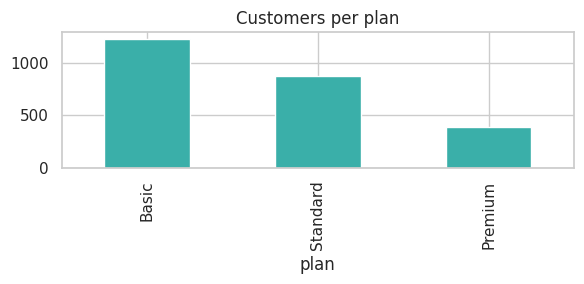

In [10]:
# -----------------------------------------------------------
# 🔹 4A. CATEGORY FREQUENCIES
# -----------------------------------------------------------
print('Plan mix:')
print(df['plan'].value_counts(normalize=True).round(3))
print('\nTop cities:')
print(df['city'].value_counts().head(5))

fig, ax = plt.subplots(figsize=(6, 3))
df['plan'].value_counts().plot(kind='bar', ax=ax, color='#3AAFA9')
ax.set_title('Customers per plan'); plt.tight_layout(); plt.show()

Churn vs retained proportions:
is_churned
0    0.834
1    0.166
Name: proportion, dtype: float64

Imbalance ratio (retained / churned): 5.024096385542169


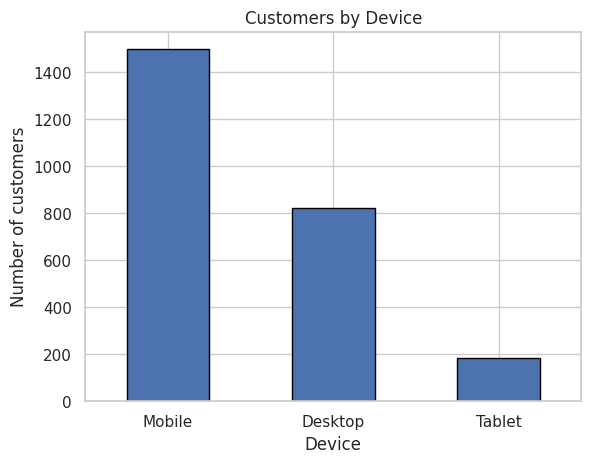

In [11]:
# 1. Churn vs retained proportions
churn_proportions = df['is_churned'].value_counts(normalize=True)

print("Churn vs retained proportions:")
print(churn_proportions)

# 2. Imbalance ratio (retained / churned)
counts = df['is_churned'].value_counts()

retained = counts.get(0, 0)
churned = counts.get(1, 0)

imbalance_ratio = retained / churned

print("\nImbalance ratio (retained / churned):", imbalance_ratio)

# 3. Bar chart of device
df['device'].value_counts().plot(
    kind='bar',
    edgecolor='black'
)

plt.xlabel('Device')
plt.ylabel('Number of customers')
plt.title('Customers by Device')
plt.xticks(rotation=0)
plt.show()

# Dominant category: Mobile is expected to be the dominant device category.

5. Bivariate analysis — numeric vs numeric

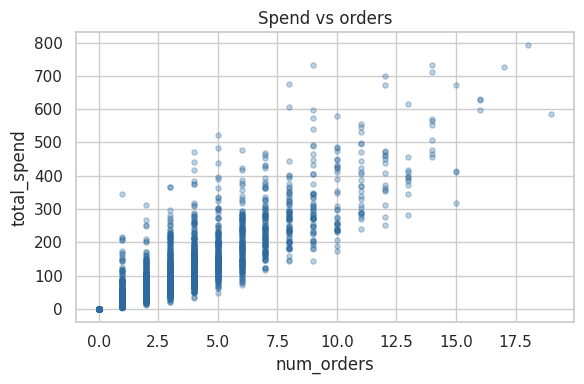

correlation: 0.864


In [12]:
# -----------------------------------------------------------
# 🔹 5A. DO SPEND AND ORDER COUNT MOVE TOGETHER?
# -----------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(df['num_orders'], df['total_spend'], alpha=0.3, color='#2D6A9F', s=14)
ax.set_xlabel('num_orders'); ax.set_ylabel('total_spend')
ax.set_title('Spend vs orders'); plt.tight_layout(); plt.show()

print('correlation:', round(df['num_orders'].corr(df['total_spend']), 3))

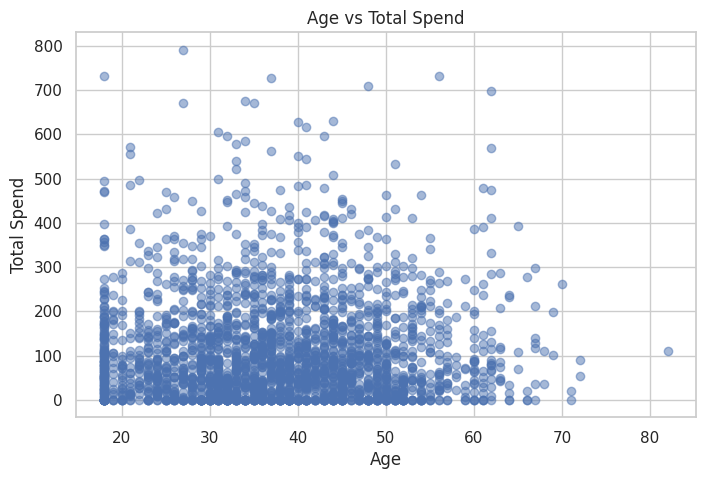

Correlation between age and total_spend: 0.006797896800715421


In [13]:
# 1. Scatter plot: age vs total_spend
plt.figure(figsize=(8, 5))

plt.scatter(
    df['age'],
    df['total_spend'],
    alpha=0.5
)

plt.xlabel('Age')
plt.ylabel('Total Spend')
plt.title('Age vs Total Spend')
plt.show()

# 2. Correlation
correlation = df['age'].corr(df['total_spend'])

print("Correlation between age and total_spend:", correlation)

# 3. Interpretation:
# The correlation indicates the strength and direction of the linear
# relationship between age and spending. A value close to 0 suggests
# little linear relationship. Correlation does not imply causation.

6. Bivariate analysis — numeric vs categorical (churned vs retained)

            num_orders  total_spend  support_tickets
is_churned                                          
0                  3.6        125.5              0.6
1                  1.4         45.9              0.7


/tmp/ipykernel_1431/3518072038.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='is_churned', y='num_orders', ax=ax,


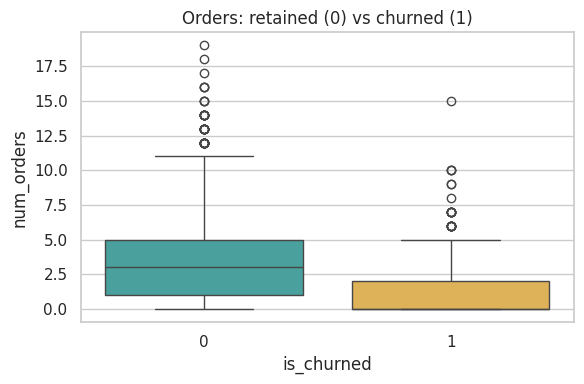

In [14]:
# -----------------------------------------------------------
# 🔹 6A. HOW DO CHURNERS DIFFER?  (group means)
# -----------------------------------------------------------
cols = ['num_orders', 'total_spend', 'support_tickets']
print(df.groupby('is_churned')[cols].mean().round(1))

fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(data=df, x='is_churned', y='num_orders', ax=ax,
            palette=['#3AAFA9', '#F4B942'])
ax.set_title('Orders: retained (0) vs churned (1)')
plt.tight_layout(); plt.show()

Mean support tickets by churn status:
is_churned
0    0.58801
1    0.73253
Name: support_tickets, dtype: float64


<Figure size 700x500 with 0 Axes>

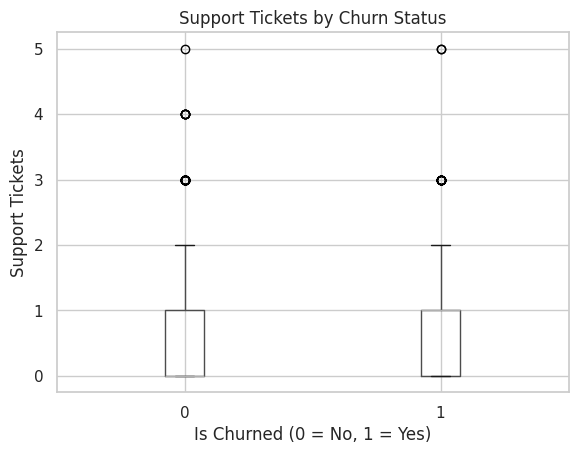

In [15]:
# 1. Mean support_tickets by churn status
mean_tickets = df.groupby('is_churned')['support_tickets'].mean()

print("Mean support tickets by churn status:")
print(mean_tickets)

# 2. Box plot of support_tickets by is_churned
plt.figure(figsize=(7, 5))

df.boxplot(
    column='support_tickets',
    by='is_churned'
)

plt.xlabel('Is Churned (0 = No, 1 = Yes)')
plt.ylabel('Support Tickets')
plt.title('Support Tickets by Churn Status')
plt.suptitle('')  # Remove pandas' automatic subtitle
plt.show()

# 3. Is it a warning sign?
# Yes, support tickets can be treated as a potential churn warning sign
# if churned customers show a higher mean/median number of tickets.
# This is an association, not proof that tickets cause churn.


7. Multivariate — the correlation heatmap

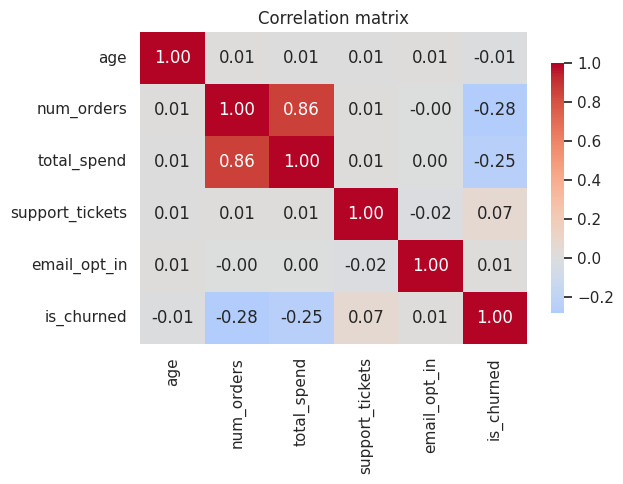

Correlation with churn (sorted):
num_orders        -0.282144
total_spend       -0.252546
age               -0.010746
email_opt_in       0.011145
support_tickets    0.068880
Name: is_churned, dtype: float64


In [16]:
# -----------------------------------------------------------
# 🔹 7A. WHAT CORRELATES WITH CHURN?
# -----------------------------------------------------------
num = ['age', 'num_orders', 'total_spend', 'support_tickets',
       'email_opt_in', 'is_churned']
corr = df[num].corr()

fig, ax = plt.subplots(figsize=(6.5, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            ax=ax, cbar_kws={'shrink': .8})
ax.set_title('Correlation matrix'); plt.tight_layout(); plt.show()

print('Correlation with churn (sorted):')
print(corr['is_churned'].drop('is_churned').sort_values())

In [17]:
# 1. Top-2 absolute correlations with churn
corr = df.corr(numeric_only=True)

top2 = (
    corr['is_churned']
    .drop('is_churned')
    .abs()
    .sort_values(ascending=False)
    .head(2)
)

print("Top 2 features most correlated with churn:")
print(top2)

# 2. Direction of each driver:
# Positive correlation -> higher feature values are associated with MORE churn.
# Negative correlation -> higher feature values are associated with LESS churn.
# In this dataset, more orders should be associated with less churn,
# while greater recency/support-related values may be associated with more churn

Top 2 features most correlated with churn:
num_orders     0.282144
total_spend    0.252546
Name: is_churned, dtype: float64


8. Grouping & aggregation — which segments churn?

In [18]:
# -----------------------------------------------------------
# 🔹 8A. CHURN RATE BY SEGMENT
# -----------------------------------------------------------
print('Churn rate by plan:')
print(df.groupby('plan')['is_churned'].mean().round(3).sort_values(ascending=False))

print('\nChurn rate by device x plan:')
print(df.pivot_table(values='is_churned', index='plan',
                     columns='device', aggfunc='mean').round(3))

Churn rate by plan:
plan
Standard    0.174
Basic       0.163
Premium     0.158
Name: is_churned, dtype: float64

Churn rate by device x plan:
device    Desktop  Mobile  Tablet
plan                             
Basic       0.163   0.163   0.162
Premium     0.133   0.168   0.176
Standard    0.168   0.179   0.159


In [19]:
# 1. Churn rate by payment_method
payment_churn = df.groupby('payment_method')['is_churned'].mean()

print("Churn rate by payment method:")
print(payment_churn)

# 2. Pivot: churn rate by plan x email_opt_in
plan_email_churn = pd.pivot_table(
    df,
    values='is_churned',
    index='plan',
    columns='email_opt_in',
    aggfunc='mean'
)

print("\nChurn rate by plan and email opt-in:")
print(plan_email_churn)

# 3. Worst-churning segment:
# Find the plan/email_opt_in combination with the highest observed churn rate.
worst_segment = plan_email_churn.stack().idxmax()
worst_rate = plan_email_churn.stack().max()

print(
    f"\nHighest observed churn-rate segment: "
    f"plan={worst_segment[0]}, email_opt_in={worst_segment[1]}, "
    f"churn rate={worst_rate:.3f}"
)


Churn rate by payment method:
payment_method
Card          0.175097
NetBanking    0.150943
UPI           0.168998
Wallet        0.143266
Name: is_churned, dtype: float64

Churn rate by plan and email opt-in:
email_opt_in         0         1
plan                            
Basic         0.157407  0.165835
Premium       0.170370  0.151394
Standard      0.159864  0.180887

Highest observed churn-rate segment: plan=Standard, email_opt_in=1, churn rate=0.181


9. EDA red flags — the things that bite you later

In [20]:

# -----------------------------------------------------------
# 🔹 9A. OUTLIERS IN SPEND (IQR rule)
# -----------------------------------------------------------
q1, q3 = df['total_spend'].quantile([0.25, 0.75])
iqr = q3 - q1
high = q3 + 1.5 * iqr
outliers = df[df['total_spend'] > high]
print(f'IQR upper bound: {high:.0f}')
print('Whale customers above it:', len(outliers))
print(outliers[['customer_id', 'num_orders', 'total_spend']]
      .sort_values('total_spend', ascending=False).head())

IQR upper bound: 365
Whale customers above it: 110
     customer_id  num_orders  total_spend
812    CUST00813          18       791.37
1176   CUST01177          14       732.79
875    CUST00876           9       732.24
562    CUST00563          17       727.37
768    CUST00769          14       710.47


In [21]:
# 1. Skew of total_spend
spend_skew = df['total_spend'].skew()
print("total_spend skew:", spend_skew)

# 2. Churn rate (rare-class share)
churn_rate = df['is_churned'].mean()
print("Churn rate:", churn_rate)

# 3. Column with the most missing values
missing_pct = df.isna().mean() * 100
most_missing_col = missing_pct.idxmax()

print("Column with most missing values:", most_missing_col)
print("Missing percentage:", missing_pct.max())

# 4. One fix per flag:
# skew -> apply a log1p transformation to total_spend.
# imbalance -> use class weights or an appropriate resampling strategy.
# missing -> impute missing values (e.g. median for numeric, 'Unknown' for categorical).


total_spend skew: 1.731732234873782
Churn rate: 0.166
Column with most missing values: first_order_date
Missing percentage: 14.760000000000002
